## SPREAD LOCATOR

Intuition:

This cell loads all required libraries:

NumPy → numerical calculations
Pandas → dataset handling
Matplotlib → plotting graphs
SciPy & Statsmodels → statistical distributions and tests

We load the dataset into a DataFrame to analyze it.
head() helps us quickly understand the structure (columns like date, amount, etc.).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    "figure.figsize": (8,5),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

PASTEL = {
    "blue": "#A7C7E7",
    "pink": "#F4A7B9",
    "green": "#B5EAD7",
    "purple": "#C7CEEA",
    "peach": "#FFD1BA"
}

# Load the dataset
df = pd.read_csv("spread_locator_dataset.csv")

# Display the first few rows of the dataset
df.head()



,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


Intuition:
Convert date into proper format
Extract day & week for time-based analysis
Create a transaction flag (1) → used in Bernoulli distribution
Store transaction amounts separately

In [2]:
# Convert date column (change column name if needed)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract useful time features
df['day'] = df['transaction_date'].dt.date
df['week'] = df['transaction_date'].dt.isocalendar().week

# Assuming 'transaction_amount' column exists
amounts = df['transaction_amount']

# Binary transaction occurrence (1 = exists)
df['transaction_flag'] = 1

Intuition:

Bernoulli distribution models success/failure:

Here, transaction occurs = success (1)
Mean of flag = probability of transaction occurring
Intuition:

Binomial distribution models: “How many transactions happen in a fixed time (week)?”

n = max transactions in a week
p = probability of success
Helps analyze weekly transaction patterns 

In [3]:
# Bernoulli (transaction occurrence probability)
p = df['transaction_flag'].mean()
print("Bernoulli Probability (p):", p)

# Weekly transaction count (Binomial)
weekly_counts = df.groupby('week')['transaction_flag'].sum()

# Fit Binomial (estimate n and p)
n = weekly_counts.max()
p_binom = weekly_counts.mean() / n

print("Binomial parameters -> n:", n, ", p:", p_binom)

Bernoulli Probability (p): 1.0
Binomial parameters -> n: 56 , p: 0.6547619047619048


Intuition:

Poisson distribution models:
 “How many events occur per time interval?”

Used for daily transactions
λ (lambda) = average transactions per day
If histogram ≈ Poisson curve → good fit

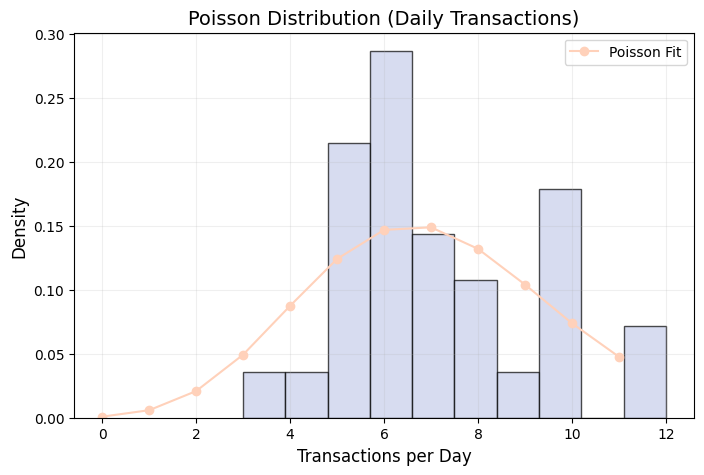

In [11]:
daily_counts = df.groupby('day').size()
lambda_poisson = daily_counts.mean()

plt.hist(daily_counts, density=True, alpha=0.7,
         color=PASTEL["purple"], edgecolor='black')

x = range(0, max(daily_counts))
plt.plot(x, stats.poisson.pmf(x, lambda_poisson),
         marker='o', color=PASTEL["peach"], label="Poisson Fit")

plt.title("Poisson Distribution (Daily Transactions)")
plt.xlabel("Transactions per Day")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


Intuition:

Log-normal is used when:
  Data is right-skewed (large values more spread out)

Transaction amounts usually follow this pattern:

Many small transactions
Few very large transactions

Power law checks:
 “Are large transactions rare but very impactful?”

Used in:

Financial systems
Risk modeling

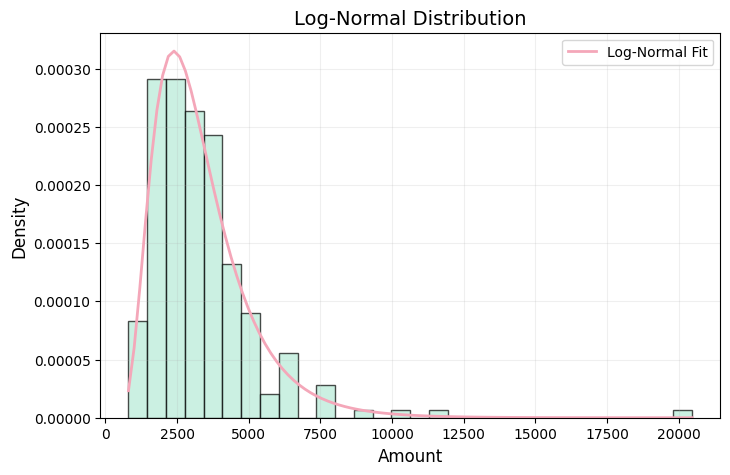

In [12]:
# Log-Normal Fit
shape, loc, scale = stats.lognorm.fit(amounts, floc=0)

plt.hist(amounts, bins=30, density=True, alpha=0.7,
         color=PASTEL["green"], edgecolor='black')

x = np.linspace(min(amounts), max(amounts), 100)
pdf_lognorm = stats.lognorm.pdf(x, shape, loc, scale)

plt.plot(x, pdf_lognorm, color=PASTEL["pink"], linewidth=2, label="Log-Normal Fit")

plt.title("Log-Normal Distribution")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Intuition:

Q-Q Plot compares:
  Your data vs Normal distribution

Straight line → data is normal
Curved line → data is NOT normal

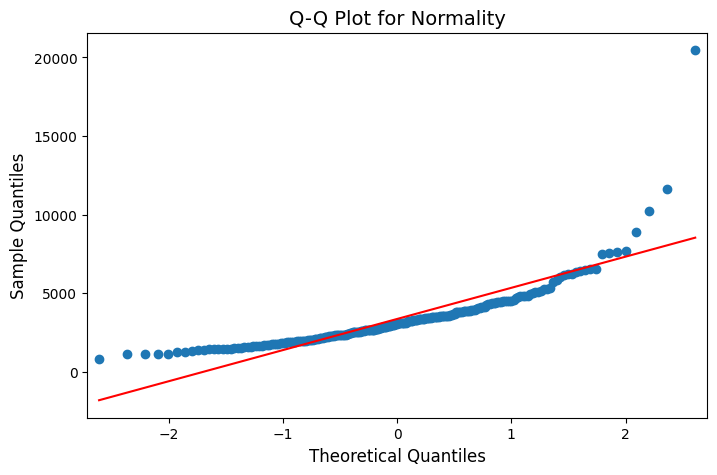

In [10]:
sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot for Normality")
plt.show()

Intuition:

Box-Cox:
 Makes skewed data more normal

Why important?

Many statistical tests require normal data
Improves model accuracy

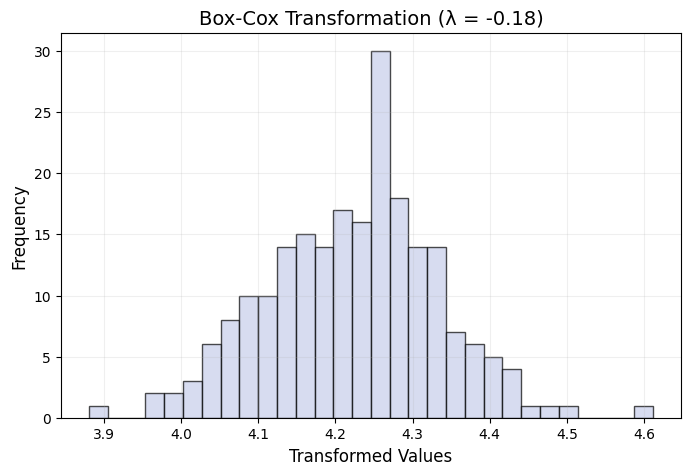

In [14]:
amounts_positive = amounts[amounts > 0]
boxcox_data, lambda_bc = stats.boxcox(amounts_positive)

plt.hist(boxcox_data, bins=30, alpha=0.7,
         color=PASTEL["purple"], edgecolor='black')

plt.title(f"Box-Cox Transformation (λ = {round(lambda_bc,2)})")
plt.xlabel("Transformed Values")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

Intuition:
Z-score → how far a value is from mean
Probability calculation →
 “How likely is a transaction above ₹5000?”

In [8]:
z_scores = stats.zscore(amounts)

mean = np.mean(amounts)
std = np.std(amounts)

prob = 1 - stats.norm.cdf(5000, mean, std)

print("Probability (Amount > 5000):", prob)

Probability (Amount > 5000): 0.20463879284661513


Intuition:
PDF → probability at a point
CDF → cumulative probability

Helps understand:
 Distribution behavior of transaction amounts

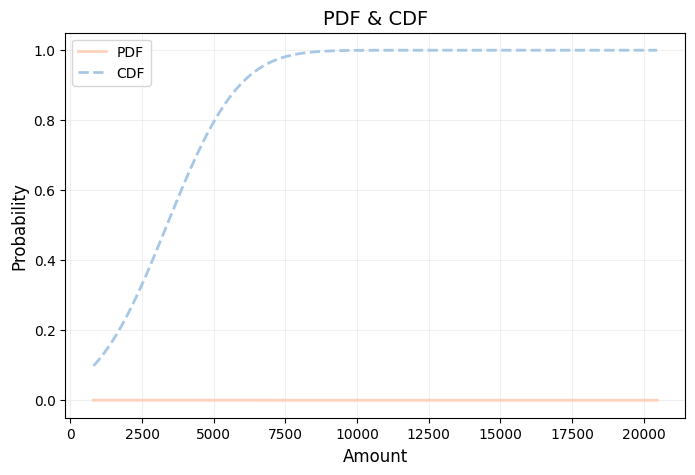

In [17]:
mean = np.mean(amounts)
std = np.std(amounts)

x = np.linspace(min(amounts), max(amounts), 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, pdf, color=PASTEL["peach"], linewidth=2, label="PDF")
plt.plot(x, cdf, color=PASTEL["blue"], linestyle='--', linewidth=2, label="CDF")

plt.title("PDF & CDF")
plt.xlabel("Amount")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Conclusion:

- Transaction amounts are right-skewed → best modeled by Log-Normal distribution.
- Daily transactions follow Poisson distribution.
- Q-Q plot shows data is not normally distributed.
- Box-Cox transformation improves normality.
- Probability of transactions above ₹5000 is low, indicating high-value transactions are rare.